In [1]:
import msprime
import numpy as np  # Importing NumPy for numerical operations
import os  # Importing os for operating system functionalities
import argparse  # Importing argparse for command-line argument parsing
import pandas as pd  # Importing pandas for DataFrame manipulation
import zipfile  # Importing zipfile for creating zip archives
import gzip
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import tskit as ts
import itertools


In [16]:

trees_file_sim_beta_sawtooth = ts.load("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/SINGER_trees/Trees_different_demographies/SawToothSim_Beta_r1e-08_m1e-07_0.trees")


In [17]:
trees_file_sim_beta_sawtooth.sequence_length

1000000.0

In [18]:
def compute_pairwise_coalescence_time(ts, leaf_index1, leaf_index2, s):
    windows = np.arange(0, ts.sequence_length, s)
    windows = np.append(windows, ts.sequence_length)
    
    # Compute pairwise diversity (this gives branch length for pairwise coalescence)
    times = ts.diversity(sample_sets=[leaf_index1, leaf_index2], windows=windows, mode='branch') / 2
    
    return times

def compute_all_pairwise_coalescence_times(ts, s):
    windows = np.arange(0, ts.sequence_length, s)
    n = len(windows)
    pairs = list(itertools.combinations(ts.samples(), 2))  # All unique pairs of samples
    m = len(pairs)
    
    # Initialize the array to store all coalescence times
    all_coalescence_times = np.zeros((n, m))
    
    # Compute coalescence time for each pair
    for index, (leaf_index1, leaf_index2) in enumerate(pairs):
        #print(f"Computing pair: {leaf_index1}, {leaf_index2}")
        all_coalescence_times[:, index] = compute_pairwise_coalescence_time(ts, leaf_index1, leaf_index2, s)
    
    return all_coalescence_times, pairs


In [19]:
interval_size = 10000
    
all_coalescence_times_Sim, pairs = compute_all_pairwise_coalescence_times(trees_file_sim_beta_sawtooth, interval_size)
print(all_coalescence_times_Sim.shape)

(100, 45)


In [20]:
all_coalescence_times_Sim

array([[57.6704768 , 32.19966332, 90.51458861, ..., 31.90403472,
        90.51458861, 90.51458861],
       [57.6704768 , 32.19966332, 90.51458861, ..., 31.90403472,
        90.51458861, 90.51458861],
       [57.6704768 , 32.19966332, 90.51458861, ..., 31.90403472,
        90.51458861, 90.51458861],
       ...,
       [57.6704768 , 90.51458861, 90.51458861, ..., 31.90403472,
        90.51458861, 90.51458861],
       [57.6704768 , 90.51458861, 90.51458861, ..., 31.90403472,
        90.51458861, 90.51458861],
       [57.6704768 , 90.51458861, 90.51458861, ..., 31.90403472,
        90.51458861, 90.51458861]])

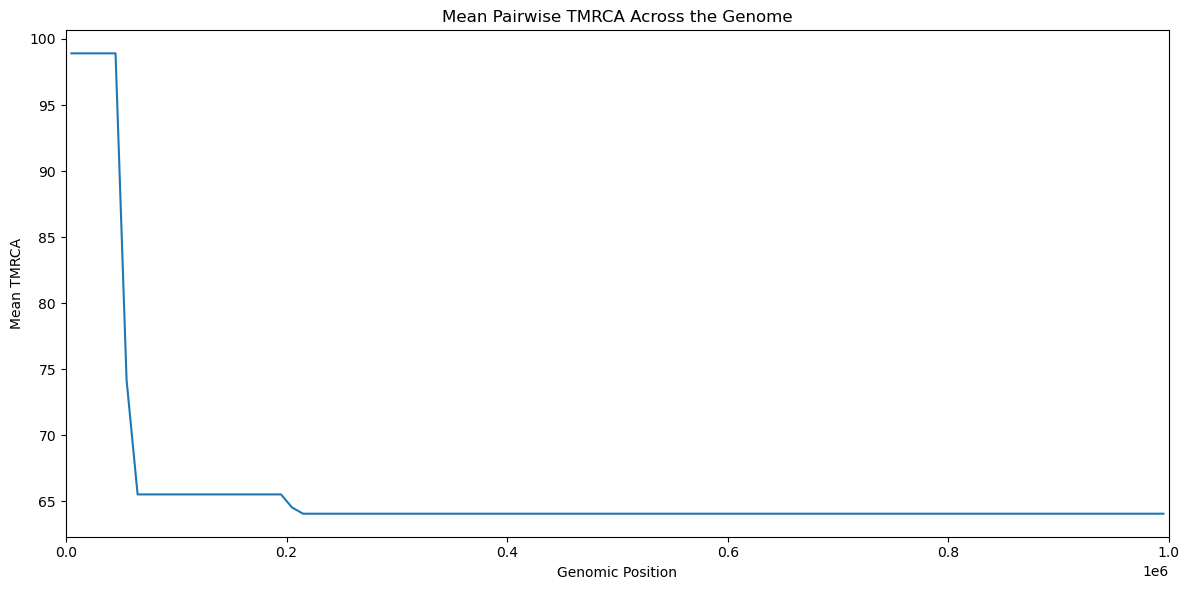

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Assuming all_coalescence_times and pairs are already calculated

# Calculate mean pairwise TMRCA for each window
mean_tmrca = np.mean(all_coalescence_times_Sim, axis=1)

# Create x-axis values (midpoints of windows)
window_midpoints = np.arange(interval_size/2, trees_file_sim_beta_sawtooth.sequence_length, interval_size)

# Plot mean pairwise TMRCA across the genome
plt.figure(figsize=(12, 6))
plt.plot(window_midpoints, mean_tmrca)
plt.title('Mean Pairwise TMRCA Across the Genome')
plt.xlabel('Genomic Position')
plt.ylabel('Mean TMRCA')
plt.xlim(0, trees_file_sim_beta_sawtooth.sequence_length)
plt.tight_layout()
plt.show()




In [22]:

def process_tree_files(folder, interval_size=10000):
    all_mean_tmrca_list = []  # Store mean TMRCA values for all trees
    tree_files = [f for f in os.listdir(folder) if f.endswith('.trees')]  # Filter for .trees files
    
    for tree_file in tree_files:
        ts_beta_inf = ts.load(os.path.join(folder, tree_file))
        
        # Compute pairwise coalescence times for this tree
        all_coalescence_times, pairs = compute_all_pairwise_coalescence_times(ts_beta_inf, interval_size)
        
        # Calculate mean pairwise TMRCA for each window
        mean_tmrca = np.mean(all_coalescence_times, axis=1)
        all_mean_tmrca_list.append(mean_tmrca)
    
    return all_mean_tmrca_list, ts_beta_inf.sequence_length

def plot_tmrca_cloud(all_mean_tmrca_list, sequence_length, interval_size=10000):
    # Create x-axis values (midpoints of windows)
    window_midpoints = np.arange(interval_size/2, sequence_length, interval_size)
    
    # Plot mean pairwise TMRCA across the genome as a translucent cloud
    plt.figure(figsize=(12, 6))
    
    # Plot inferred TMRCAs
    for i, mean_tmrca in enumerate(all_mean_tmrca_list):
        if i == 0:
            plt.plot(window_midpoints, mean_tmrca, alpha=0.99, color='lightblue', label='Inferred TMRCAs')
        else:
            plt.plot(window_midpoints, mean_tmrca, alpha=0.99, color='lightblue')
    
    # Plot the mean of all trees (simulated TMRCA)
    mean_tmrca_simulated = np.mean(all_coalescence_times_Sim, axis=1)
    plt.plot(window_midpoints, mean_tmrca_simulated, color='red', label='Simulated TMRCA')
    
    plt.title('Mean Pairwise TMRCA Across the Genome')
    plt.xlabel('Genomic Position')
    plt.ylabel('Mean TMRCA')
    plt.xlim(0, sequence_length)
    
    # Add legend
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Folder containing tree files
folder = "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/SINGER_trees/Trees_different_demographies/outputs/SawToothSim_Beta_r1e-08_m1e-07_0"

# Process all trees in the folder
all_mean_tmrca_list, sequence_length = process_tree_files(folder, interval_size=10000)
print(sequence_length)



1000000.0


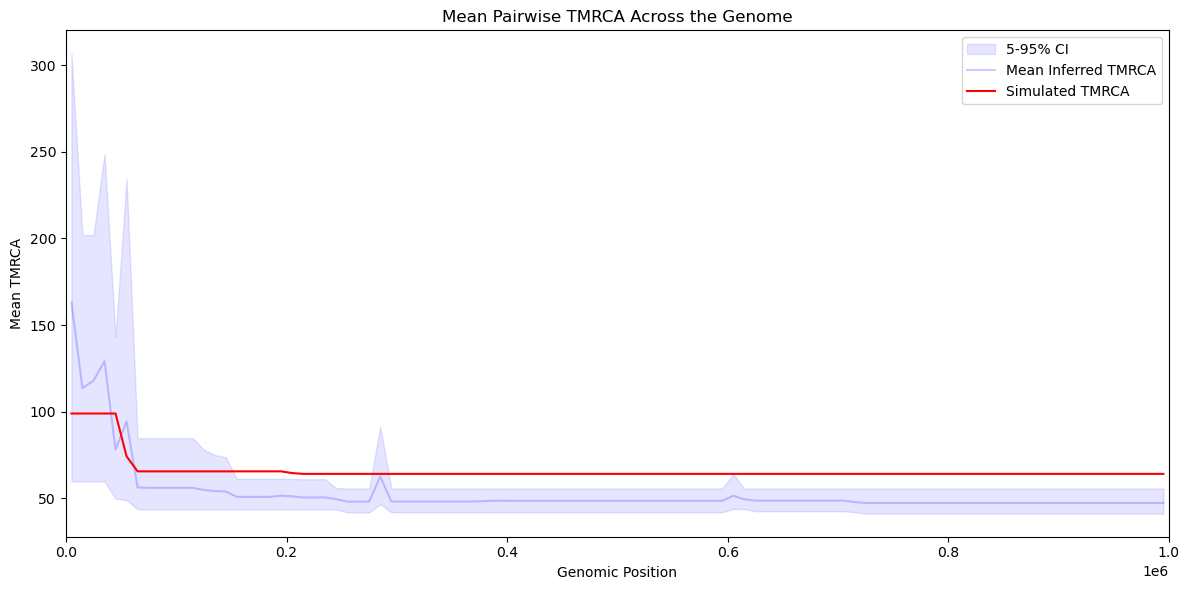

In [24]:

def process_tree_files(folder, interval_size=10000):
    all_mean_tmrca_list = []  # Store mean TMRCA values for all trees
    tree_files = [f for f in os.listdir(folder) if f.endswith('.trees')]  # Filter for .trees files
    
    for tree_file in tree_files:
        ts_beta_inf = ts.load(os.path.join(folder, tree_file))
        
        # Compute pairwise coalescence times for this tree
        all_coalescence_times, pairs = compute_all_pairwise_coalescence_times(ts_beta_inf, interval_size)
        
        # Calculate mean pairwise TMRCA for each window
        mean_tmrca = np.mean(all_coalescence_times, axis=1)
        all_mean_tmrca_list.append(mean_tmrca)
    
    return all_mean_tmrca_list, ts_beta_inf.sequence_length

def plot_tmrca_cloud(all_mean_tmrca_list, sequence_length, mean_tmrca_simulated, interval_size=10000):
    # Create x-axis values (midpoints of windows)
    window_midpoints = np.arange(interval_size/2, sequence_length, interval_size)
    
    # Convert list of arrays to 2D numpy array
    all_mean_tmrca_array = np.array(all_mean_tmrca_list)
    
    # Compute mean and confidence intervals
    mean_inferred = np.mean(all_mean_tmrca_array, axis=0)
    ci_lower = np.percentile(all_mean_tmrca_array, 5, axis=0)
    ci_upper = np.percentile(all_mean_tmrca_array, 95, axis=0)
    
    plt.figure(figsize=(12, 6))
    
    # Plot confidence interval
    plt.fill_between(window_midpoints, ci_lower, ci_upper, alpha=0.1, color='blue', label='5-95% CI')
    
    # Plot mean of inferred TMRCAs
    plt.plot(window_midpoints, mean_inferred,alpha=0.2, color='blue', label='Mean Inferred TMRCA')
    
    # Plot the mean of simulated TMRCA
    plt.plot(window_midpoints, mean_tmrca_simulated, color='red', label='Simulated TMRCA')
    
    plt.title('Mean Pairwise TMRCA Across the Genome')
    plt.xlabel('Genomic Position')
    plt.ylabel('Mean TMRCA')
    plt.xlim(0, sequence_length)
    
    # Add legend
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Folder containing tree files
folder = "/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/msprime_sims/SINGER_trees/Trees_different_demographies/outputs/SawToothSim_Beta_r1e-08_m1e-07_0"

# Process all trees in the folder
all_mean_tmrca_list, sequence_length = process_tree_files(folder, interval_size=10000)

# Compute mean of simulated TMRCA (assuming all_coalescence_times_Sim is available)
mean_tmrca_simulated = np.mean(all_coalescence_times_Sim, axis=1)

# Plot the mean TMRCA with confidence interval
plot_tmrca_cloud(all_mean_tmrca_list, sequence_length, mean_tmrca_simulated, interval_size=10000)

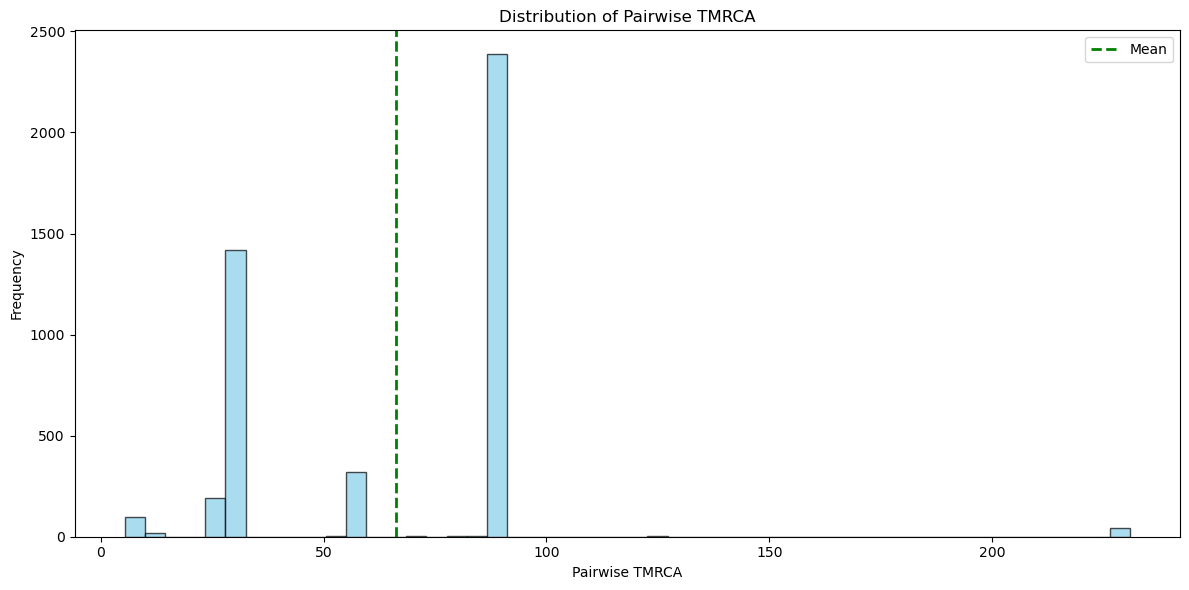

Mean TMRCA: 66.11703330984166
Median TMRCA: 90.51458860947596
Standard deviation of TMRCA: 33.57007682276


In [25]:
# Assuming all_coalescence_times is your 2D array of pairwise TMRCA values

# Flatten the array to get all pairwise TMRCA values
all_tmrca = all_coalescence_times_Sim.flatten()

# Remove any potential infinite or NaN values
all_tmrca = all_tmrca[np.isfinite(all_tmrca)]

# Create the plot
plt.figure(figsize=(12, 6))

# Histogram
plt.hist(all_tmrca, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Pairwise TMRCA')
plt.xlabel('Pairwise TMRCA')
plt.ylabel('Frequency')


# Optional: Add vertical lines for mean and median
plt.axvline(np.mean(all_tmrca), color='green', linestyle='dashed', linewidth=2, label='Mean')

plt.legend()
plt.tight_layout()
plt.show()

# Print some summary statistics
print(f"Mean TMRCA: {np.mean(all_tmrca)}")
print(f"Median TMRCA: {np.median(all_tmrca)}")
print(f"Standard deviation of TMRCA: {np.std(all_tmrca)}")

Text(0, 0.5, 'Frequency')

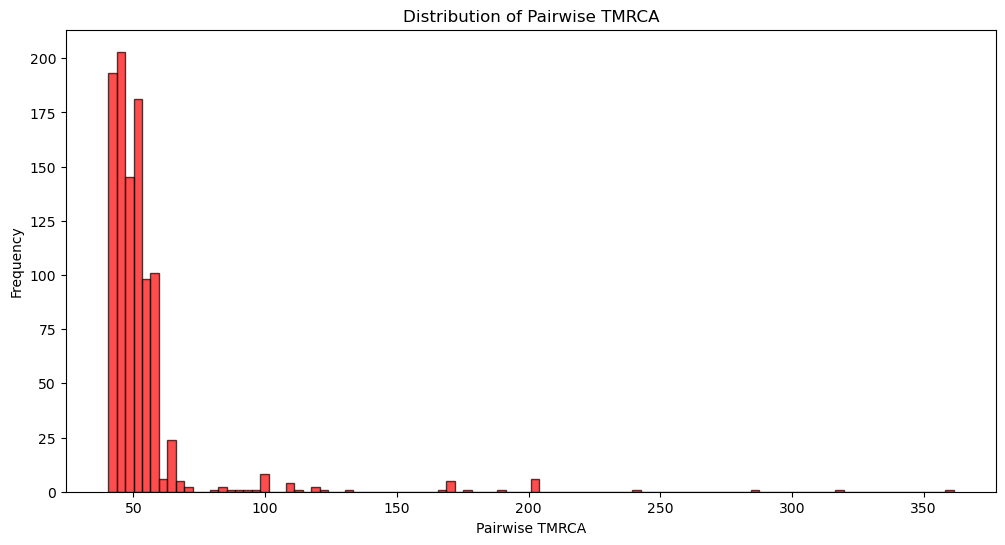

In [26]:
flat_list_allmeantmrca = []
for row in all_mean_tmrca_list:
         flat_list_allmeantmrca.extend(row)
        

# Assuming all_coalescence_times is your 2D array of pairwise TMRCA values

# Create the plot
plt.figure(figsize=(12, 6))

# Histogram

plt.hist(flat_list_allmeantmrca, bins=100, alpha=0.7, color='red', edgecolor='black',label="Inferred")
plt.title('Distribution of Pairwise TMRCA')
plt.xlabel('Pairwise TMRCA')
plt.ylabel('Frequency')



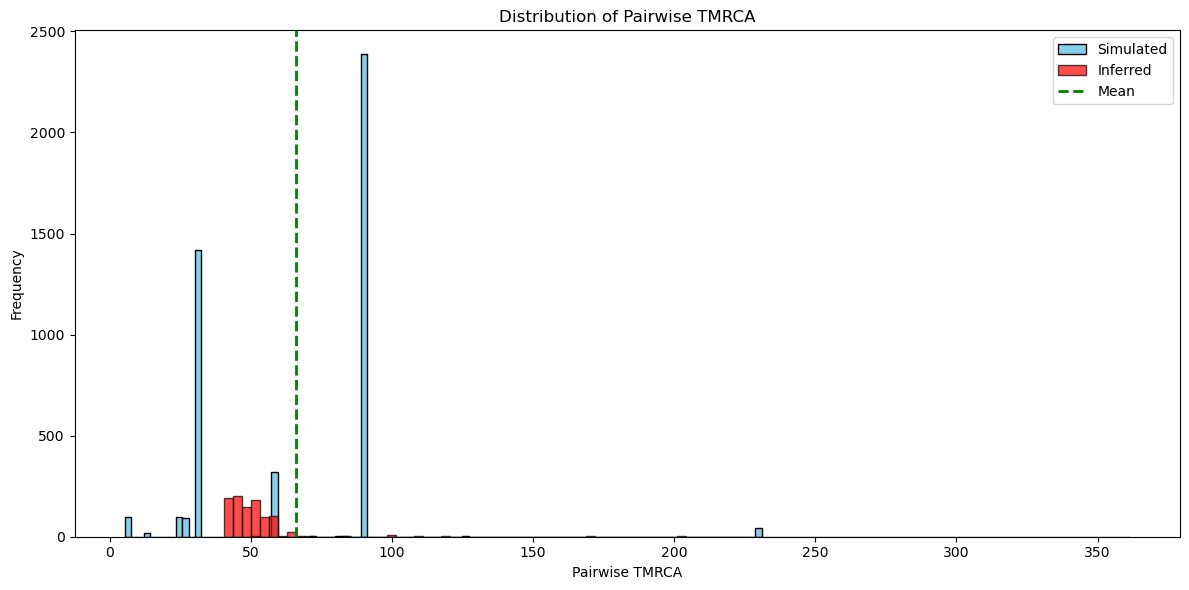

In [28]:
flat_list_allmeantmrca = []
for row in all_mean_tmrca_list:
         flat_list_allmeantmrca.extend(row)
        

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming all_coalescence_times is your 2D array of pairwise TMRCA values

# Flatten the array to get all pairwise TMRCA values
all_tmrca = all_coalescence_times_Sim.flatten()

# Remove any potential infinite or NaN values
all_tmrca = all_tmrca[np.isfinite(all_tmrca)]

# Create the plot
plt.figure(figsize=(12, 6))

# Histogram
plt.hist(all_tmrca, bins=100, alpha=1, color='skyblue', edgecolor='black',label="Simulated")
plt.hist(flat_list_allmeantmrca, bins=100, alpha=0.7, color='red', edgecolor='black',label="Inferred")
plt.title('Distribution of Pairwise TMRCA')
plt.xlabel('Pairwise TMRCA')
plt.ylabel('Frequency')


# Optional: Add vertical lines for mean and median
plt.axvline(np.mean(all_tmrca), color='green', linestyle='dashed', linewidth=2, label='Mean')

plt.legend()
plt.tight_layout()
plt.show()



In [ ]:

# Plot heatmap of pairwise coalescence times
plt.figure(figsize=(12, 10))
sns.heatmap(all_coalescence_times.T, cmap='viridis', xticklabels=50, yticklabels=False)
plt.title('Pairwise Coalescence Times Across the Genome')
plt.xlabel(f'Genomic Position ({interval_size} bp windows)')
plt.ylabel('Sample Pairs')
cbar = plt.colorbar(label='Coalescence Time')
cbar.set_label('Coalescence Time', rotation=270, labelpad=15)

# Add pair labels to y-axis
plt.yticks(np.arange(len(pairs)) + 0.5, [f'{p[0]}_{p[1]}' for p in pairs], rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

# Plot mean coalescence time across the genome
mean_coalescence_time = np.mean(all_coalescence_times, axis=1)
plt.figure(figsize=(12, 6))
plt.plot(np.arange(0, ts.sequence_length, interval_size), mean_coalescence_time)
plt.title('Mean Pairwise Coalescence Time Across the Genome')
plt.xlabel('Genomic Position')
plt.ylabel('Mean Coalescence Time')
plt.tight_layout()
plt.show()

# Save results to CSV with indices separated by '_'
df = pd.DataFrame(all_coalescence_times)
pair_labels = [f"{i[0]}_{i[1]}" for i in pairs]
df.columns = pair_labels
df.to_csv('coalescence_times.csv', index=False)

# Also save the genomic positions
positions = np.arange(0, ts.sequence_length, interval_size)
df_with_positions = pd.DataFrame({'Position': positions})
df_with_positions = pd.concat([df_with_positions, df], axis=1)
df_with_positions.to_csv('coalescence_times_with_positions.csv', index=False)
